# **Temporal Growth Trajectories Using Long Short-Term Memory (LSTM) Networks**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


2025-02-11 08:47:31.691742: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

file_path = "/Users/mac/Documents/RESEARCH WORK/Machine learning origianl.xlsx"
data = pd.read_excel(file_path)


print(data.head())


  SEX_CHILD  Religion:  SEX_HH_HEAD  AGE_MOTHER  HH_SIZE Place of residence  \
0    Female          1            2          25        3              Rural   
1      Male          1            2          20        4              Rural   
2    Female          2            2          35        5              Rural   
3      Male          1            2          21        3              Rural   
4    Female          2            1          35        4              Rural   

  Ethnicity  AGE_CHILD_DAYS  WT_CHILD_KG  Height_Child__CM  HT_CHILD_Metre  \
0    Yoruba          1380.0          5.3             73.00          0.7300   
1    Yoruba          1470.0         11.8             86.01          0.8601   
2    Yoruba          1110.0          9.6            100.80          1.0080   
3    Yoruba           270.0          6.2             66.60          0.6660   
4    Yoruba           330.0          8.1             67.00          0.6700   

   HT_CHILD_Metre^2  Weight_Mother_KG  Height_Mother_CM 

In [3]:

print(data.dtypes)

SEX_CHILD                 object
Religion:                  int64
SEX_HH_HEAD                int64
AGE_MOTHER                 int64
HH_SIZE                    int64
Place of residence        object
Ethnicity                 object
AGE_CHILD_DAYS           float64
WT_CHILD_KG              float64
Height_Child__CM         float64
HT_CHILD_Metre           float64
HT_CHILD_Metre^2         float64
Weight_Mother_KG         float64
Height_Mother_CM         float64
Height_Mother_Metre      float64
Height_Mother_Metre^2    float64
BMI_CHILD                float64
BMI_MOTHER               float64
dtype: object


In [4]:
categorical_columns = ["SEX_CHILD", "Place of residence", "Ethnicity"]
label_encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    label_encoders[col] = encoder 


In [5]:
features = [
    "AGE_CHILD_DAYS", "WT_CHILD_KG", "Height_Child__CM", "BMI_CHILD",
    "Weight_Mother_KG", "Height_Mother_CM", "BMI_MOTHER",
    "HH_SIZE", "SEX_CHILD", "Place of residence", "Ethnicity"
]
target = "WT_CHILD_KG"

X = data[features].values
y = data[target].values


In [6]:
train_size = int(len(data) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [7]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))


In [8]:
sequence_length = 5 
batch_size = 32

train_generator = TimeseriesGenerator(X_train, y_train, length=sequence_length, batch_size=batch_size)
test_generator = TimeseriesGenerator(X_test, y_test, length=sequence_length, batch_size=batch_size)


In [9]:

model = Sequential([
    LSTM(64, activation="relu", return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    Dropout(0.2),
    LSTM(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)  
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [10]:
history = model.fit(train_generator, epochs=50, validation_data=test_generator)


Epoch 1/50
19/19 [==============================] - 3s 29ms/step - loss: 0.0126 - mae: 0.0840 - val_loss: 0.0068 - val_mae: 0.0385
Epoch 2/50
19/19 [==============================] - 0s 16ms/step - loss: 0.0047 - mae: 0.0430 - val_loss: 0.0081 - val_mae: 0.0441
Epoch 3/50
19/19 [==============================] - 0s 8ms/step - loss: 0.0043 - mae: 0.0388 - val_loss: 0.0072 - val_mae: 0.0379
Epoch 4/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0043 - mae: 0.0388 - val_loss: 0.0073 - val_mae: 0.0385
Epoch 5/50
19/19 [==============================] - 0s 9ms/step - loss: 0.0043 - mae: 0.0382 - val_loss: 0.0077 - val_mae: 0.0409
Epoch 6/50
19/19 [==============================] - 0s 11ms/step - loss: 0.0043 - mae: 0.0381 - val_loss: 0.0075 - val_mae: 0.0394
Epoch 7/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0042 - mae: 0.0375 - val_loss: 0.0074 - val_mae: 0.0389
Epoch 8/50
19/19 [==============================] - 0s 9ms/step - loss: 0.0042 - mae:

5/5 [==============================] - 0s 3ms/step
Mean Squared Error: 50.0968
Mean Absolute Error: 3.1966


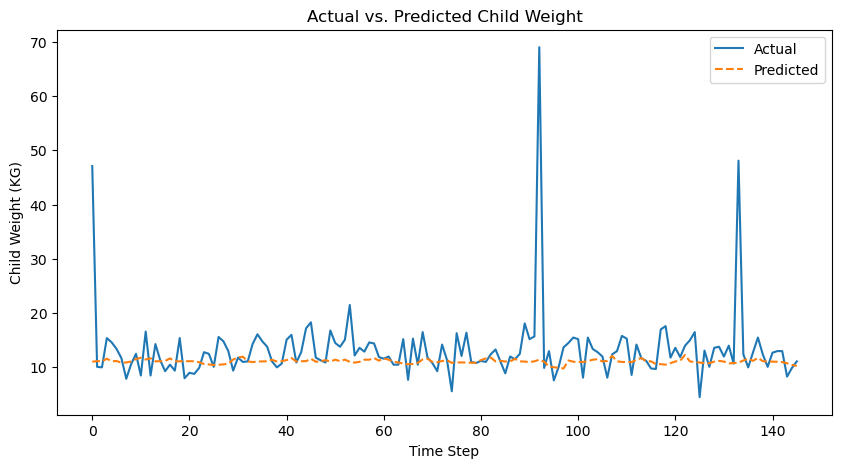

In [11]:

predictions = model.predict(test_generator)

predictions = scaler_y.inverse_transform(predictions)
y_test_actual = scaler_y.inverse_transform(y_test[sequence_length:])  

mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted", linestyle="dashed")
plt.xlabel("Time Step")
plt.ylabel("Child Weight (KG)")
plt.title("Actual vs. Predicted Child Weight")
plt.legend()
plt.show()


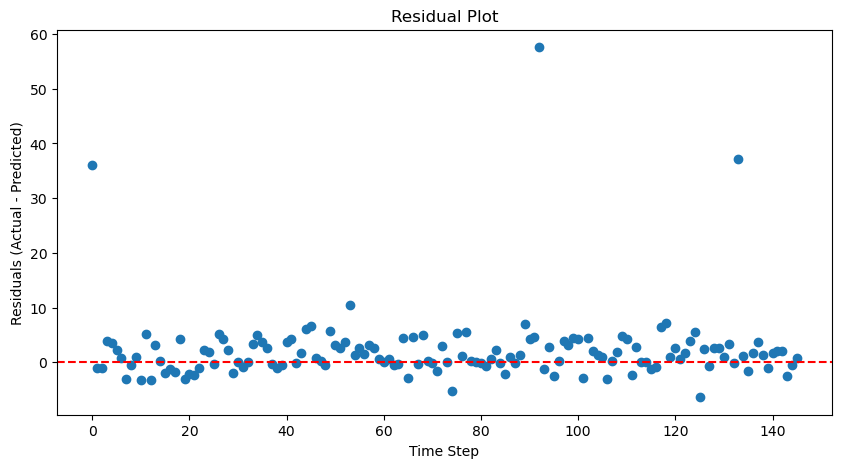

In [12]:
residuals = y_test_actual - predictions

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Time Step")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


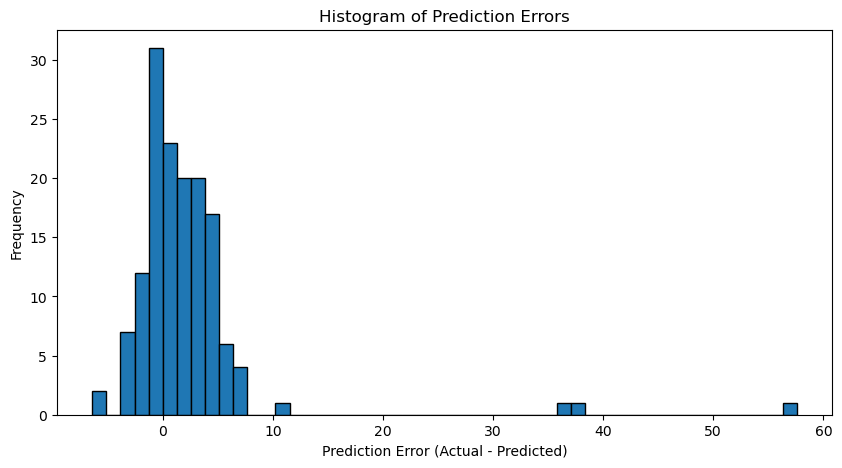

In [13]:
errors = y_test_actual - predictions

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Errors")
plt.show()


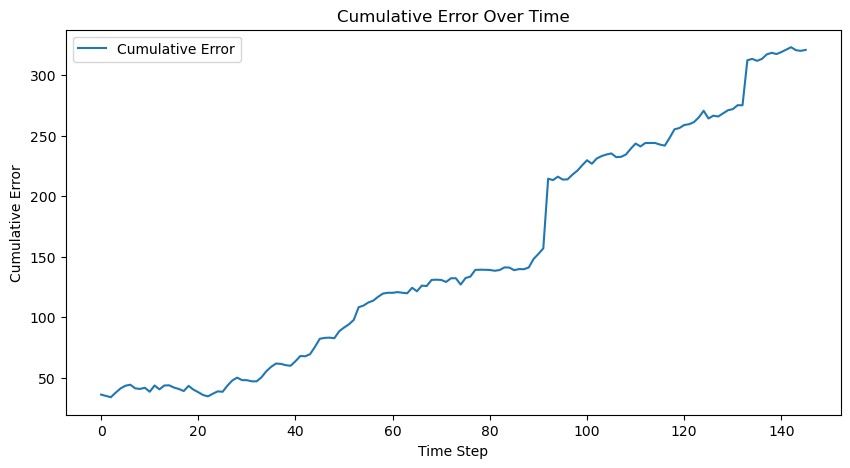

In [14]:
cumulative_error = np.cumsum(errors)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_error, label="Cumulative Error")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Error")
plt.title("Cumulative Error Over Time")
plt.legend()
plt.show()


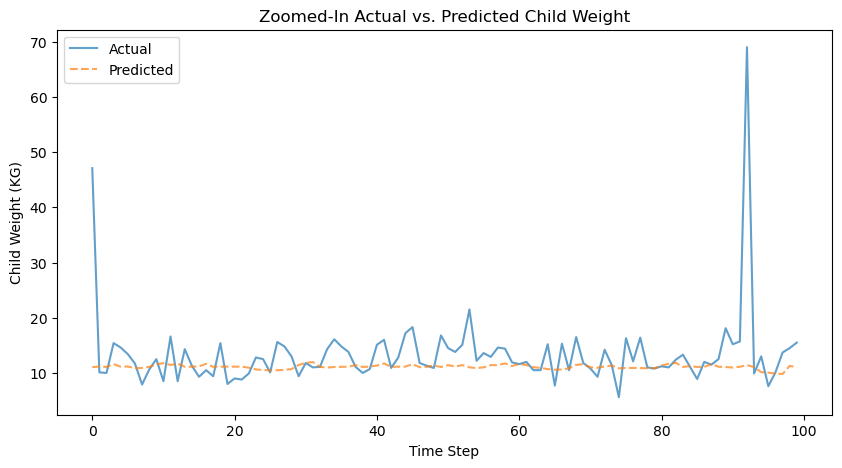

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual[:100], label="Actual", alpha=0.7)
plt.plot(predictions[:100], label="Predicted", linestyle="dashed", alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Child Weight (KG)")
plt.title("Zoomed-In Actual vs. Predicted Child Weight")
plt.legend()
plt.show()
